In [1]:
# %pip install tifffile imagecodecs

In [18]:
import tifffile as tiff
import matplotlib.pyplot as plt
import numpy as np

img = tiff.imread("20191228_103958_25.xif_hi.tif")

print(img.dtype, img.min(), img.max())


uint16 3508 50760


In [ ]:
img_norm = (img - img.min()) / (img.max() - img.min())

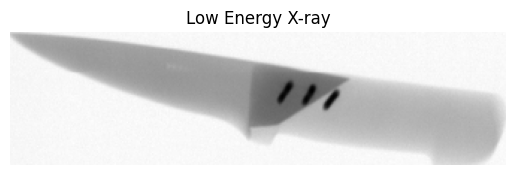

In [21]:
plt.imshow(img_norm, cmap="gray")
plt.title("Low Energy X-ray")
plt.axis("off")
plt.show()


In [22]:
p1, p99 = np.percentile(img, (1, 99))
img_norm = np.clip((img - p1) / (p99 - p1), 0, 1)


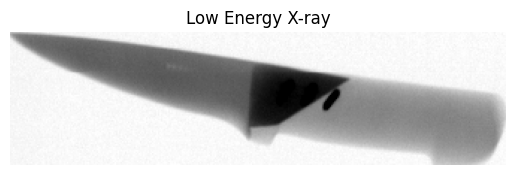

In [23]:
plt.imshow(img_norm, cmap="gray")
plt.title("Low Energy X-ray")
plt.axis("off")
plt.show()


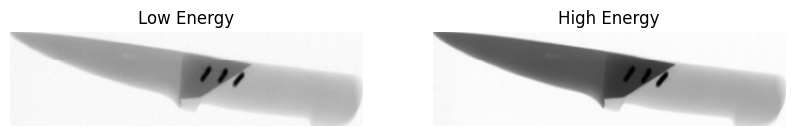

In [25]:
low = tiff.imread("20191228_103958_25.xif_hi.tif")
high = tiff.imread("20191228_103958_25.xif_lo.tif")

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(low, cmap="gray")
plt.title("Low Energy")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(high, cmap="gray")
plt.title("High Energy")
plt.axis("off")

plt.show()


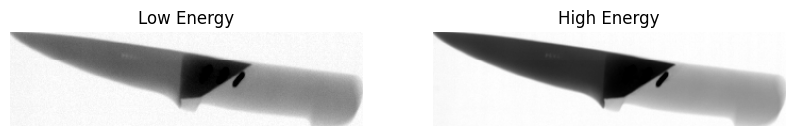

In [24]:
low = tiff.imread("20191228_103958_25.xif_hi.tif")
high = tiff.imread("20191228_103958_25.xif_lo.tif")

def norm(x):
    p1, p99 = np.percentile(x, (1, 99))
    return np.clip((x - p1) / (p99 - p1), 0, 1)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(norm(low), cmap="gray")
plt.title("Low Energy")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(norm(high), cmap="gray")
plt.title("High Energy")
plt.axis("off")

plt.show()


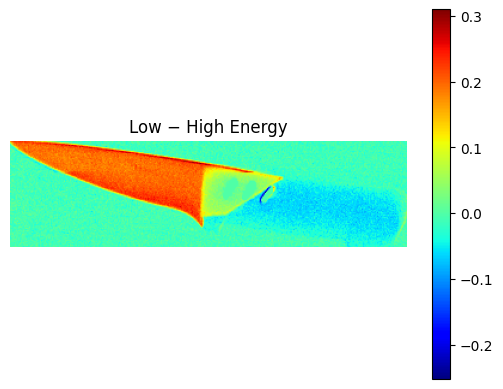

In [26]:
material_map = norm(low) - norm(high)

plt.imshow(material_map, cmap="jet")
plt.colorbar()
plt.title("Low − High Energy")
plt.axis("off")
plt.show()

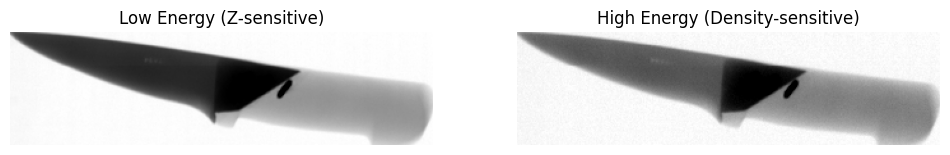

In [27]:
def norm(x):
    p2, p98 = np.percentile(x, (2, 98))
    return np.clip((x - p2) / (p98 - p2), 0, 1)

le_n = norm(high)
he_n = norm(low)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(le_n, cmap="gray")
plt.title("Low Energy (Z-sensitive)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(he_n, cmap="gray")
plt.title("High Energy (Density-sensitive)")
plt.axis("off")

plt.show()



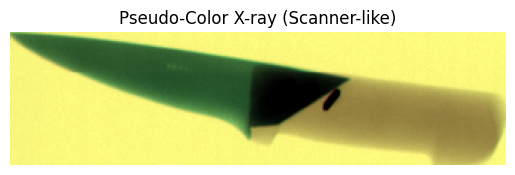

In [28]:
R = le_n
G = he_n
B = he_n * 0.5

rgb = np.stack([R, G, B], axis=-1)
plt.imshow(rgb)
plt.title("Pseudo-Color X-ray (Scanner-like)")
plt.axis("off")
plt.show()


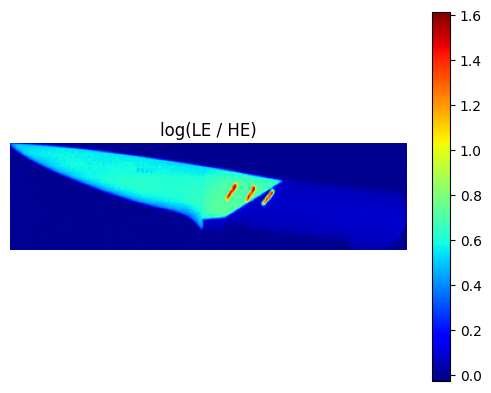

In [29]:
eps = 1e-6
ratio = np.log(low + eps) - np.log(high + eps)

plt.imshow(ratio, cmap="jet")
plt.colorbar()
plt.title("log(LE / HE)")
plt.axis("off")
plt.show()


In [30]:
low = np.flipud(low)
high = np.flipud(high)

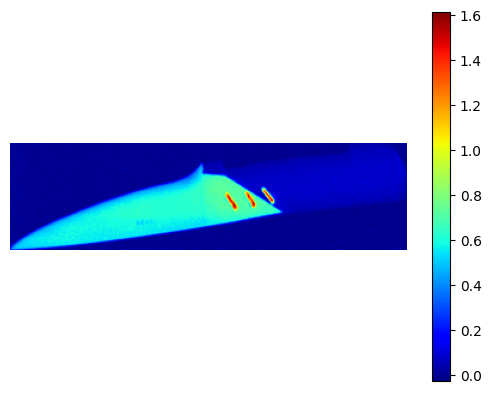

In [32]:
eps = 1e-6
ratio = np.log(low + eps) - np.log(high + eps)

plt.imshow(ratio, cmap="jet")
plt.colorbar()
plt.axis("off")
plt.show()


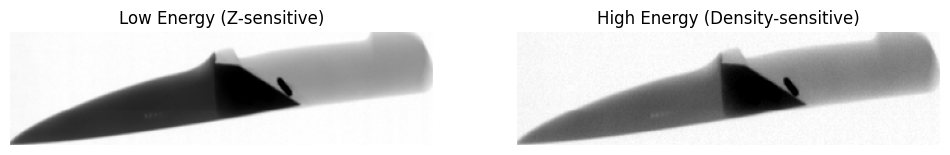

In [33]:
def norm(x):
    p2, p98 = np.percentile(x, (2, 98))
    return np.clip((x - p2) / (p98 - p2), 0, 1)

le_n = norm(high)
he_n = norm(low)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(le_n, cmap="gray")
plt.title("Low Energy (Z-sensitive)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(he_n, cmap="gray")
plt.title("High Energy (Density-sensitive)")
plt.axis("off")

plt.show()

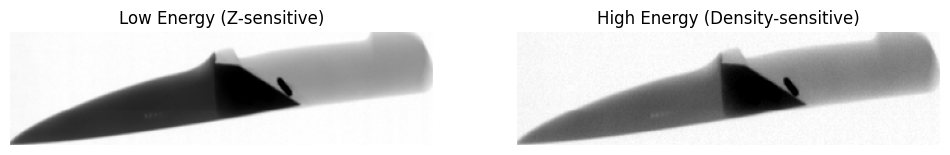

In [34]:
def norm(x):
    p2, p98 = np.percentile(x, (2, 98))
    return np.clip((x - p2) / (p98 - p2), 0, 1)

le_n = norm(high)
he_n = norm(low)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(le_n, cmap="gray")
plt.title("Low Energy (Z-sensitive)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(he_n, cmap="gray")
plt.title("High Energy (Density-sensitive)")
plt.axis("off")

plt.show()


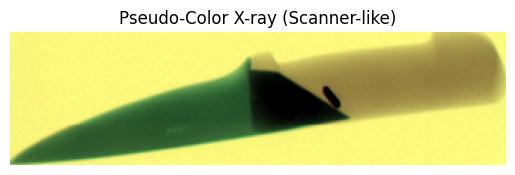

In [35]:
R = le_n
G = he_n
B = he_n * 0.5

rgb = np.stack([R, G, B], axis=-1)
plt.imshow(rgb)
plt.title("Pseudo-Color X-ray (Scanner-like)")
plt.axis("off")
plt.show()
